# Data analysis: ASD 

#### libraries

In [1]:
import glob
import os
import pandas as pd
import numpy as np
try:
    from specdal import Spectrum
except ImportError:
    Spectrum = None
    print('Warning: specdal not installed; using text parser fallback for ASD files')
import matplotlib.pyplot as plt
import math
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist, squareform
from sklearn.preprocessing import StandardScaler
from scipy.signal import find_peaks

### Cleaned-up previous functions; applicable to all datasets

In [2]:
def normalise_asd_filename(filepath):
    filename = os.path.basename(filepath)
    if filename.lower().endswith('.asd.txt'):
        return filename[:-8]
    if filename.lower().endswith('.asd'):
        return filename[:-4]
    return filename

In [3]:

def load_asd_data(data_folder):
    """
    Load ASD files from the specified folder and combine into a DataFrame.
    Supports both *.asd and *.asd.txt.
    """
    if not os.path.isdir(data_folder):
        raise FileNotFoundError(f"Data folder not found: {data_folder}")

    patterns = ['*.asd', '*.asd.txt']
    files = []
    for pat in patterns:
        files.extend(glob.glob(os.path.join(data_folder, pat)))
    files = sorted(set(files))

    if not files:
        print(f"No ASD files found in {data_folder}")
        return None

    dfs = []
    for f in files:
        if not os.path.isfile(f):
            continue

        name = normalise_asd_filename(f)
        parsed_df = None

        # prefer Spectrum if available and file ends with .asd
        if Spectrum is not None and f.lower().endswith('.asd') and not f.lower().endswith('.asd.txt'):
            try:
                spec = Spectrum(filepath=f)
                parsed_df = spec.measurement.to_frame(name=name)
            except Exception as e:
                print(f"Spectrum parser failed for {f}: {e}")
                parsed_df = None

        # fallback text parser for .asd.txt (and .asd if Spectrum not available)
        if parsed_df is None:
            try:
                # data starts at line 2 (first line header-ish)
                fallback = pd.read_csv(f, delim_whitespace=True, header=None, skiprows=1, names=['wavelength', 'reflectance'])
                fallback = fallback.set_index('wavelength')
                parsed_df = fallback.rename(columns={'reflectance': name})
            except Exception as e:
                print(f"Fallback txt parser failed for {f}: {repr(e)}")
                parsed_df = None

        if parsed_df is None:
            print(f"Skipping {f} due to parse failure")
            continue

        dfs.append(parsed_df)


    if not dfs:
        print("No valid files loaded.")
        return None

    alldata = pd.concat(dfs, axis=1)
    alldata['Avg refl'] = alldata.mean(axis=1)
    print("Data loaded successfully. Shape:", alldata.shape)
    print(alldata.head())
    return alldata


#### Create average + plot average plot of the total asd dataset
physical meaning is 0 but still useful

In [4]:
def plot_average_spectrum(alldata, name="average_spectrum.png"):
    """
    Plot the average spectrum.
    Parameters: alldata (pd.DataFrame): DataFrame with spectral data
    """
    plt.plot(alldata.index, alldata['Avg refl'])
    plt.xlabel("Wavelength (nm)")
    plt.ylabel("Reflectance")
    plt.title(name)
    plt.show()


#clustering data based o nthe spectral distance; euclidean distances used

In [5]:
def perform_clustering(alldata, num_clusters=None):
    """
    Perform hierarchical clustering on the spectral data.
    Parameters:
    alldata (pd.DataFrame): DataFrame with spectral data
    num_clusters (int): Number of clusters (optional, defaults to 16)
    """
    spectrum_data = alldata.drop('Avg refl', axis=1) #added prior

    # Compute pairwise distances
    distances = pdist(spectrum_data.T, metric='euclidean')
    linkage_matrix = linkage(distances, method='ward') #so overview of how close spectra are lcoatied to each other overall 
    
    if num_clusters is None:
        num_clusters = 16   # Default value; set by readability of graph
    
    cluster_labels = fcluster(linkage_matrix, num_clusters, criterion='maxclust')

    cluster_assignment = pd.DataFrame({
        'Sample': spectrum_data.columns,
        'Cluster': cluster_labels
    })
    
    cluster_averages = {} # Compute cluster averages; to get average cluster spectrum
    for cluster_id in range(1, num_clusters + 1):
        members = cluster_assignment[cluster_assignment['Cluster'] == cluster_id]['Sample'].tolist()
        cluster_data = spectrum_data[members]
        cluster_avg = cluster_data.mean(axis=1)
        cluster_averages[cluster_id] = cluster_avg
    
    return linkage_matrix, cluster_assignment, num_clusters, cluster_averages

###### oke, now weird sutff; get dendogram; basically shows "heritage idfferent spectra"

physical use is bascially 0 as there are so many spectra in the sets it is more or less unreadable 

In [6]:
def plot_dendrogram(linkage_matrix, spectrum_data, name="dendrogram.png"):
    """
    Plot the hierarchical clustering dendrogram.
    
    Parameters:
    linkage_matrix: Linkage matrix from clustering
    spectrum_data (pd.DataFrame): Spectral data
    """
    plt.figure(figsize=(16, 8))
    dendrogram(linkage_matrix, labels=spectrum_data.columns.astype(str), leaf_rotation=90)
    plt.xlabel('Spectrum Sample')
    plt.ylabel('Distance (Euclidean)')
    plt.title('Hierarchical Clustering Dendrogram based on Spectral Similarity')
    plt.savefig(name, dpi=300, bbox_inches='tight')
    plt.show()

In [7]:
def plot_spectra_and_averages(spectrum_data, cluster_assignment, num_clusters, cluster_averages, name_All="all_spectra_clusters.png", name_clus="cluster_averages.png"):
    """
    Plot all spectra colored by cluster and cluster averages.
    Parameters:
    spectrum_data (pd.DataFrame): Spectral data
    cluster_assignment (pd.DataFrame): Cluster assignments
    num_clusters (int): Number of clusters
    cluster_averages (dict): Cluster average spectra
    """
    #I like viridis, change to whatever fiery you like and enjoy
    colors = plt.cm.viridis(np.linspace(0, 1, num_clusters))

    # so this will be all the clusters plotted; these are averages of very similar clusters
    plt.figure(figsize=(12, 6))
    for idx, sample in enumerate(spectrum_data.columns):
        cluster_id = cluster_assignment[cluster_assignment['Sample'] == sample]['Cluster'].values[0]
        color = colors[cluster_id - 1]
        plt.plot(spectrum_data.index, spectrum_data[sample], alpha=0.3, color=color, linewidth=0.8)
    plt.xlabel('Wavelength (nm)')
    plt.ylabel('Reflectance')
    plt.title('All Spectra Grouped by Cluster (colored)')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(name_All, dpi=300, bbox_inches='tight')
    plt.show()

    # Cluster averages; print number of members in each cluster in legend; these are averages of very similar clusters
    plt.figure(figsize=(12, 6))
    for cluster_id in range(1, num_clusters + 1):
        cluster_avg = cluster_averages[cluster_id]
        members = cluster_assignment[cluster_assignment['Cluster'] == cluster_id]['Sample'].tolist()
        color = colors[cluster_id - 1]
        plt.plot(spectrum_data.index, cluster_avg, label=f'Cluster {cluster_id} (n={len(members)})',
                 linewidth=2.5, color=color)
    plt.xlabel('Wavelength (nm)')
    plt.ylabel('Reflectance')
    plt.title('Average Spectra per Cluster')
    plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(name_clus, dpi=300, bbox_inches='tight')
    plt.show()

def print_cluster_summary(cluster_assignment, num_clusters): # so this is mainly to get to shows which clusters consist of which spectra 
    """
    Print summary of cluster assignments.
    Parameters:
    cluster_assignment (pd.DataFrame): Cluster assignments
    num_clusters (int): Number of clusters
    """
    print("Cluster Assignment:")
    print(cluster_assignment)
    print(f"\nNumber of clusters: {num_clusters}")
    for i in range(1, num_clusters + 1):
        members = cluster_assignment[cluster_assignment['Cluster'] == i]['Sample'].tolist()
        print(f"Cluster {i}: {len(members)} samples - {members[:5]}{'...' if len(members) > 5 else ''}")
    
    print("\nCluster Summary:")
    for cluster_id in range(1, num_clusters + 1):
        members = cluster_assignment[cluster_assignment['Cluster'] == cluster_id]['Sample'].tolist()
        print(f"Cluster {cluster_id}: {len(members)} samples")


Final function; get the extrema highlighted; (not if small and swiggley); gets you info on which wavelengths to check for 

In [8]:
def analyze_extrema(cluster_averages, cluster_assignment, name="cluster_extrema.png"):
    """
    Analyze and plot extrema (peaks and valleys) for each cluster.
    Parameters:
    cluster_averages (dict): Cluster average spectra
    cluster_assignment (pd.DataFrame): Cluster assignments
    """
    cluster_ids = sorted(cluster_averages.keys())
    fig, axs = plt.subplots(len(cluster_ids), 1, figsize=(14, 4 * len(cluster_ids)), sharex=True)
    if len(cluster_ids) == 1:
        axs = [axs]

    for i, cluster_id in enumerate(cluster_ids):
        cluster_avg = cluster_averages[cluster_id]
        ax = axs[i]

        # Detect local extrema on the average spectrum with filtering
        maxima_idx, _ = find_peaks(cluster_avg.values, distance=20, prominence=0.01)
        minima_idx, _ = find_peaks(-cluster_avg.values, distance=20, prominence=0.01)

        # Plot average curve
        ax.plot(cluster_avg.index, cluster_avg.values, color='tab:blue', linewidth=2, label=f'Cluster {cluster_id} avg')

        # Vertical lines: maxima / minima
        for idx in maxima_idx:
            ax.axvline(cluster_avg.index[idx], color='green', linestyle='--', alpha=0.5)
        for idx in minima_idx:
            ax.axvline(cluster_avg.index[idx], color='red', linestyle='--', alpha=0.5)

        # Mark the points
        ax.scatter(cluster_avg.index[maxima_idx], cluster_avg.values[maxima_idx], color='green', s=30, marker='^', label='max')
        ax.scatter(cluster_avg.index[minima_idx], cluster_avg.values[minima_idx], color='red', s=30, marker='v', label='min')

        ax.set_title(f'Cluster {cluster_id}\n({len(cluster_assignment[cluster_assignment.Cluster==cluster_id])} samples)')
        ax.set_ylabel('Reflectance')
        ax.legend(loc='best', fontsize='small')
        ax.grid(True, alpha=0.3)

    axs[-1].set_xlabel('Wavelength (nm)')
    plt.tight_layout()
    plt.savefig(name, dpi=300, bbox_inches='tight')
    plt.show()

    # Optional summary table of extrema for each cluster
    for cluster_id in cluster_ids:
        cluster_avg = cluster_averages[cluster_id]
        maxima_idx, _ = find_peaks(cluster_avg.values, distance=20, prominence=0.01)
        minima_idx, _ = find_peaks(-cluster_avg.values, distance=20, prominence=0.01)

        max_points = list(zip(cluster_avg.index[maxima_idx], cluster_avg.values[maxima_idx]))
        min_points = list(zip(cluster_avg.index[minima_idx], cluster_avg.values[minima_idx]))

        print(f"\nCluster {cluster_id} extrema (count max={len(max_points)}, min={len(min_points)})")
        print("Maxima (wavelength, reflectance):")
        print(pd.DataFrame(max_points, columns=['Wavelength', 'Reflectance']).head(10).to_string(index=False))
        print("Minima (wavelength, reflectance):")
        print(pd.DataFrame(min_points, columns=['Wavelength', 'Reflectance']).head(10).to_string(index=False))

Data loaded successfully. Shape: (2151, 1601)
            LA24_0100000  LA24_0100001  LA24_0100002  LA24_0100003  \
wavelength                                                           
350.0           0.058464      0.054332      0.064475      0.055510   
351.0           0.060425      0.054075      0.067319      0.053822   
352.0           0.060410      0.055407      0.063300      0.053993   
353.0           0.057558      0.055819      0.057613      0.056992   
354.0           0.055485      0.050535      0.059566      0.055145   

            LA24_0100004  LA24_0100005  LA24_0100006  LA24_0100007  \
wavelength                                                           
350.0           0.049397      0.060200      0.051914      0.057938   
351.0           0.055180      0.060270      0.060017      0.057703   
352.0           0.057823      0.060900      0.064884      0.056640   
353.0           0.053747      0.061435      0.061061      0.059789   
354.0           0.055575      0.054648     

C:\Users\fionn\AppData\Local\Temp\ipykernel_22012\29315350.py:59: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  alldata['Avg refl'] = alldata.mean(axis=1)


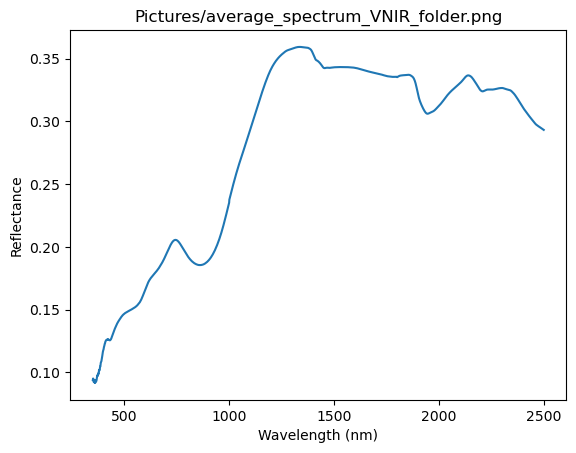

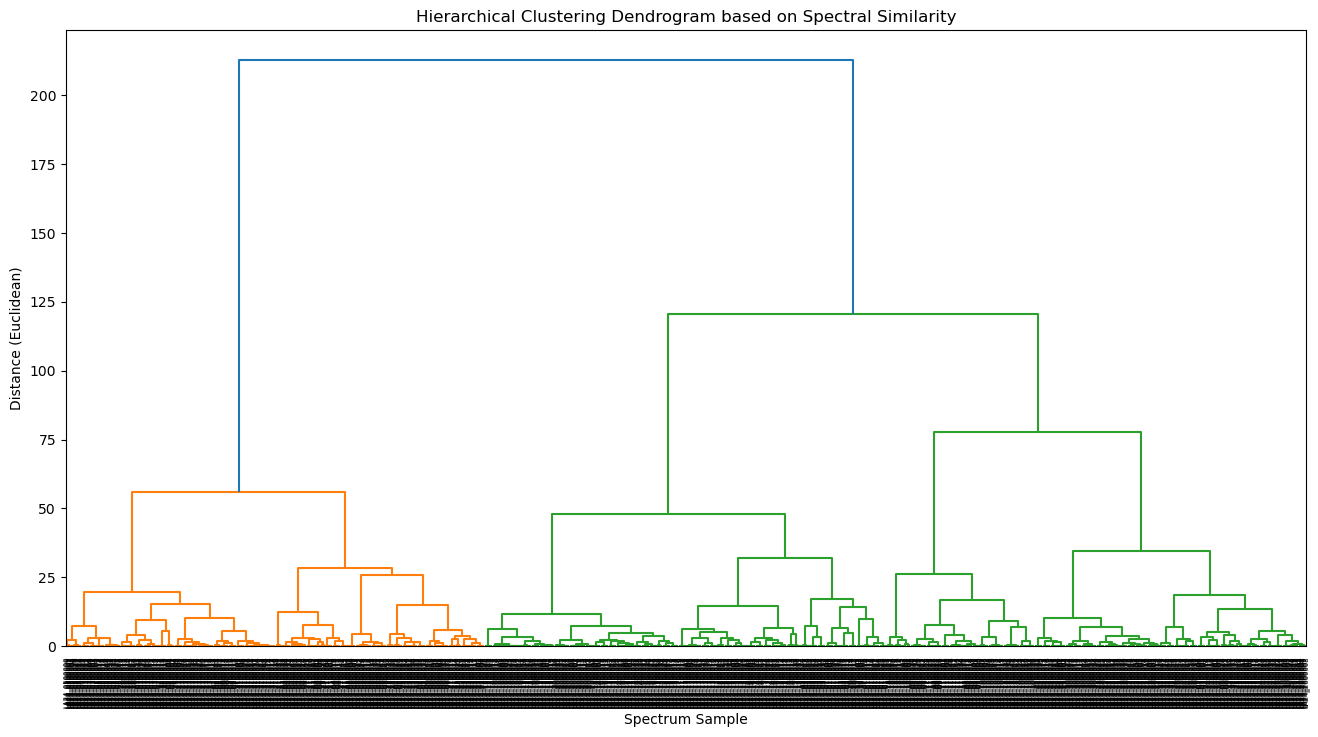

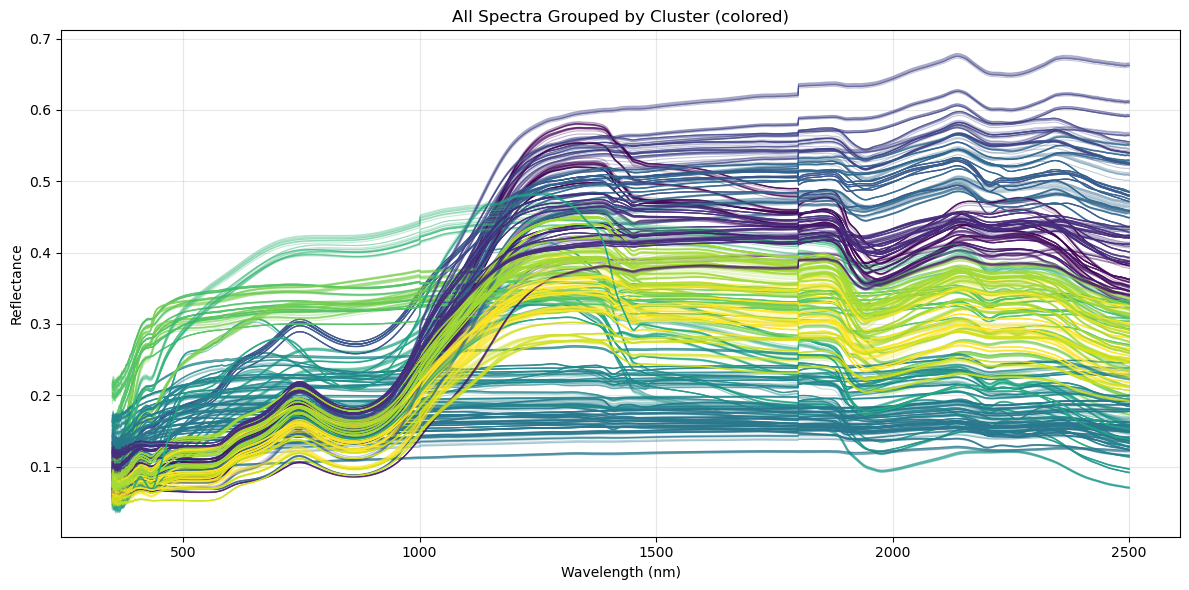

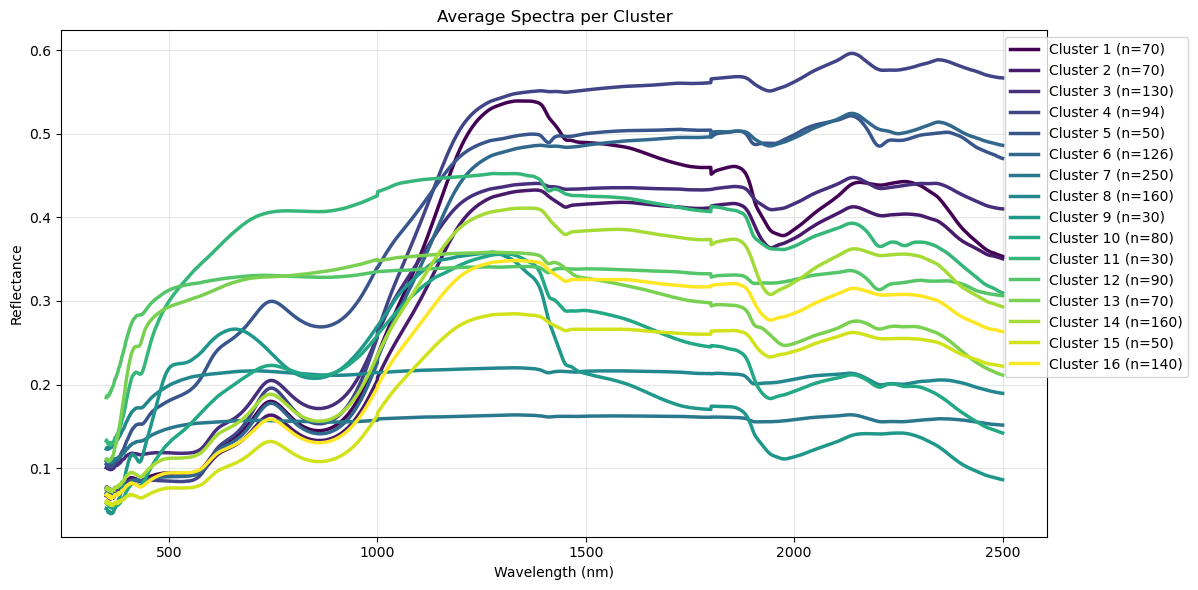

Cluster Assignment:
            Sample  Cluster
0     LA24_0100000       10
1     LA24_0100001       10
2     LA24_0100002       10
3     LA24_0100003       10
4     LA24_0100004       10
...            ...      ...
1595  LA24_3200045       15
1596  LA24_3200046       15
1597  LA24_3200047       15
1598  LA24_3200048       15
1599  LA24_3200049       15

[1600 rows x 2 columns]

Number of clusters: 16
Cluster 1: 70 samples - ['LA24_0500000', 'LA24_0500001', 'LA24_0500002', 'LA24_0500003', 'LA24_0500004']...
Cluster 2: 70 samples - ['LA24_0200000', 'LA24_0200001', 'LA24_0200002', 'LA24_0200003', 'LA24_0200004']...
Cluster 3: 130 samples - ['LA24_0200010', 'LA24_0200011', 'LA24_0200012', 'LA24_0200013', 'LA24_0200014']...
Cluster 4: 94 samples - ['LA24_0400000', 'LA24_0400001', 'LA24_0400002', 'LA24_0400003', 'LA24_0400004']...
Cluster 5: 50 samples - ['LA24_0800000', 'LA24_0800001', 'LA24_0800002', 'LA24_0800003', 'LA24_0800004']...
Cluster 6: 126 samples - ['LA24_0200020', 'LA24_020002

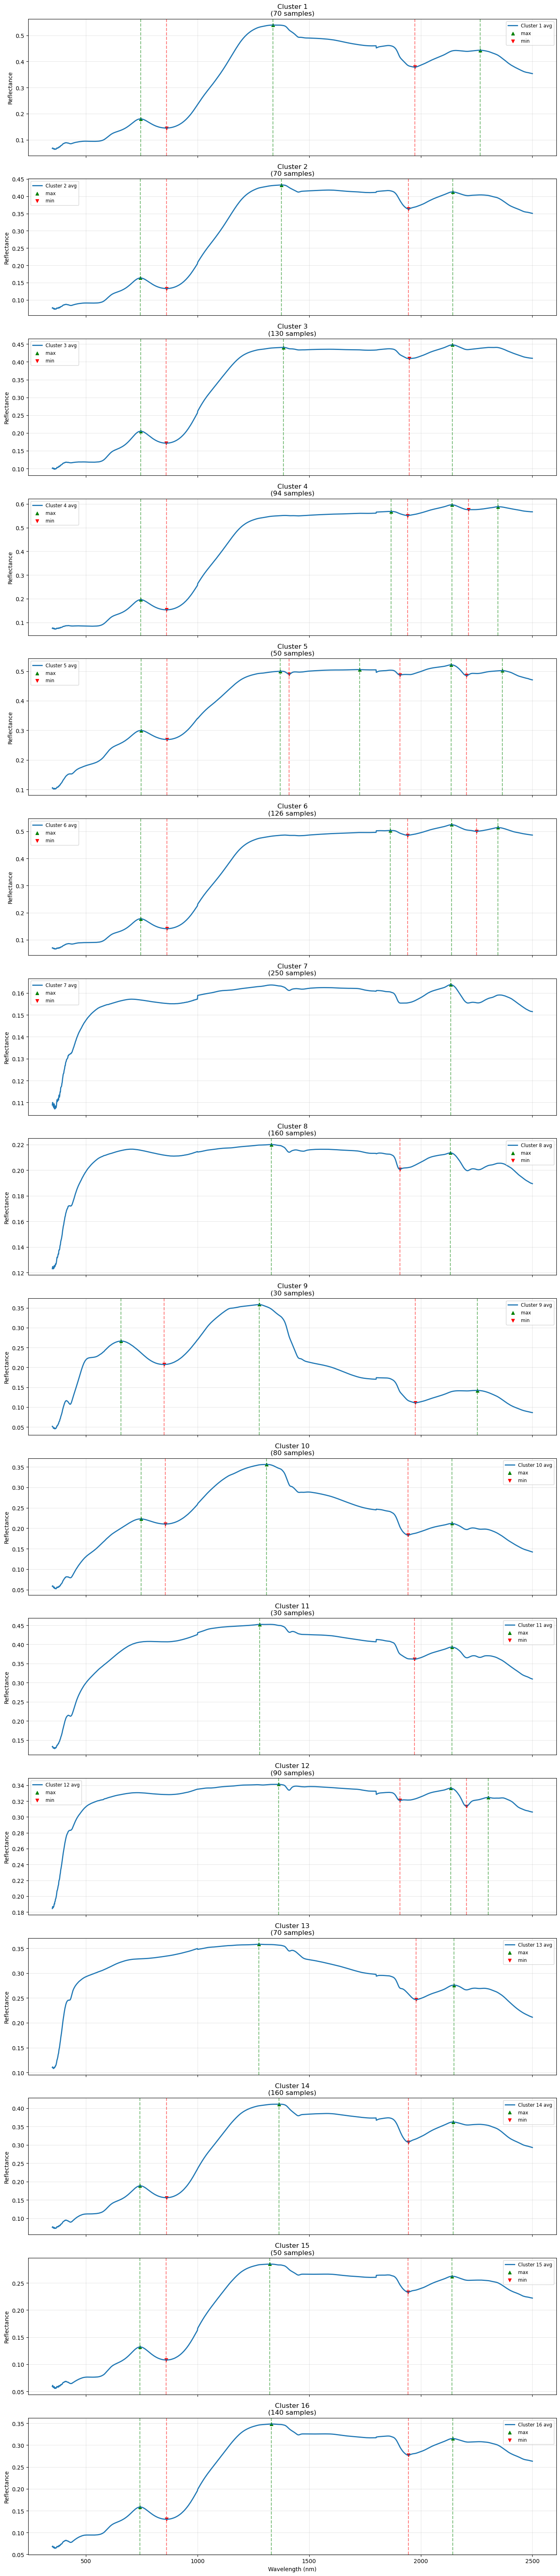


Cluster 1 extrema (count max=3, min=2)
Maxima (wavelength, reflectance):
 Wavelength  Reflectance
      745.0     0.179833
     1338.0     0.539211
     2267.0     0.442779
Minima (wavelength, reflectance):
 Wavelength  Reflectance
      862.0     0.144803
     1973.0     0.378146

Cluster 2 extrema (count max=3, min=2)
Maxima (wavelength, reflectance):
 Wavelength  Reflectance
      744.0     0.163442
     1376.0     0.432673
     2143.0     0.412561
Minima (wavelength, reflectance):
 Wavelength  Reflectance
      862.0     0.132980
     1945.0     0.363478

Cluster 3 extrema (count max=3, min=2)
Maxima (wavelength, reflectance):
 Wavelength  Reflectance
      746.0     0.204897
     1385.0     0.440549
     2141.0     0.447648
Minima (wavelength, reflectance):
 Wavelength  Reflectance
      860.0     0.171322
     1948.0     0.409190

Cluster 4 extrema (count max=4, min=3)
Maxima (wavelength, reflectance):
 Wavelength  Reflectance
      746.0     0.195736
     1867.0     0.568268
  

In [9]:
# Main execution - change the data_folder to your dataset path
data_folder = 'Data_folders/VNIR_SWIR_LG2_024/'

# Load data
alldata = load_asd_data(data_folder)
if alldata is None:
    raise ValueError("Failed to load data")

# Plot average spectrum
plot_average_spectrum(alldata, name="Pictures/average_spectrum_VNIR_folder.png")

# Perform clustering
linkage_matrix, cluster_assignment, num_clusters, cluster_averages = perform_clustering(alldata, num_clusters=16)

# Plot dendrogram
spectrum_data = alldata.drop('Avg refl', axis=1)
plot_dendrogram(linkage_matrix, spectrum_data, name="Pictures/dendrogram_VNIR_folder.png")

# Plot spectra and averages
plot_spectra_and_averages(spectrum_data, cluster_assignment, num_clusters, cluster_averages, name_All="Pictures/all_spectra_clusters_VNIR_folder.png", name_clus="Pictures/cluster_averages_VNIR_folder.png")

# Print cluster summary
print_cluster_summary(cluster_assignment, num_clusters)

# Analyze extrema
analyze_extrema(cluster_averages, cluster_assignment, name="Pictures/cluster_extrema_VNIR_folder.png")

In [10]:
# print('folder exists:', os.path.isdir('Data_folders/Group_1_ASD/'))
# print('files found:', glob.glob('Data_folders/Group_1_ASD/*.asd*')[:5])

In [11]:
# alldata = load_asd_data('Data_folders/Group_1_ASD/')
# print('shape', None if alldata is None else alldata.shape)
# print('cols', None if alldata is None else alldata.columns[:5])

In [12]:
# import os, glob
# print(os.getcwd())
# print(os.path.isdir('Data_folders/Group_1_ASD'))
# print(glob.glob('Data_folders/Group_1_ASD/*.asd*')[:10])

C:\Users\fionn\AppData\Local\Temp\ipykernel_22012\29315350.py:40: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  fallback = pd.read_csv(f, delim_whitespace=True, header=None, skiprows=1, names=['wavelength', 'reflectance'])
C:\Users\fionn\AppData\Local\Temp\ipykernel_22012\29315350.py:40: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  fallback = pd.read_csv(f, delim_whitespace=True, header=None, skiprows=1, names=['wavelength', 'reflectance'])
C:\Users\fionn\AppData\Local\Temp\ipykernel_22012\29315350.py:40: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  fallback = pd.read_csv(f, delim_whitespace=True, header=None, skiprows=1, names=['wavelength', 'reflectance'])
C:\Users\fionn\AppData\Local\Temp\ipy

Data loaded successfully. Shape: (2151, 221)
            LMW100000  LMW100001  LMW100002  LMW100003  LMW100004  LMW100005  \
wavelength                                                                     
350          0.079580   0.080831   0.077000   0.090269   0.091188   0.089229   
351          0.084687   0.080754   0.077291   0.087452   0.087328   0.084396   
352          0.081792   0.078507   0.077334   0.082550   0.076911   0.078242   
353          0.071114   0.077630   0.077074   0.079148   0.069945   0.073027   
354          0.077288   0.074543   0.077217   0.076474   0.074454   0.082326   

            LMW100006  LMW100007  LMW100008  LMW100009  ...  MM900001  \
wavelength                                              ...             
350          0.078916   0.075610   0.083040   0.084552  ...  0.068140   
351          0.086616   0.086710   0.082293   0.084969  ...  0.070841   
352          0.086428   0.085870   0.079212   0.081603  ...  0.064796   
353          0.077823   0.073

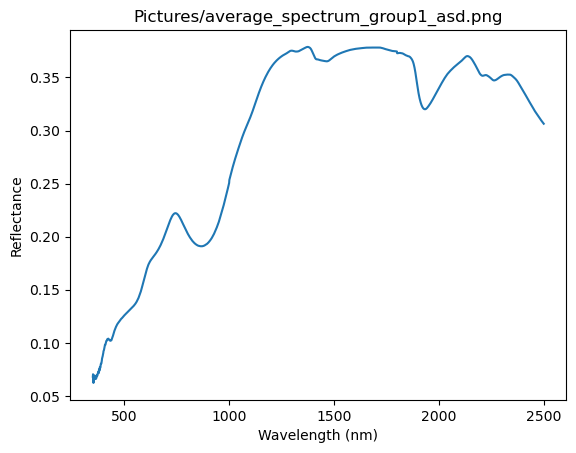

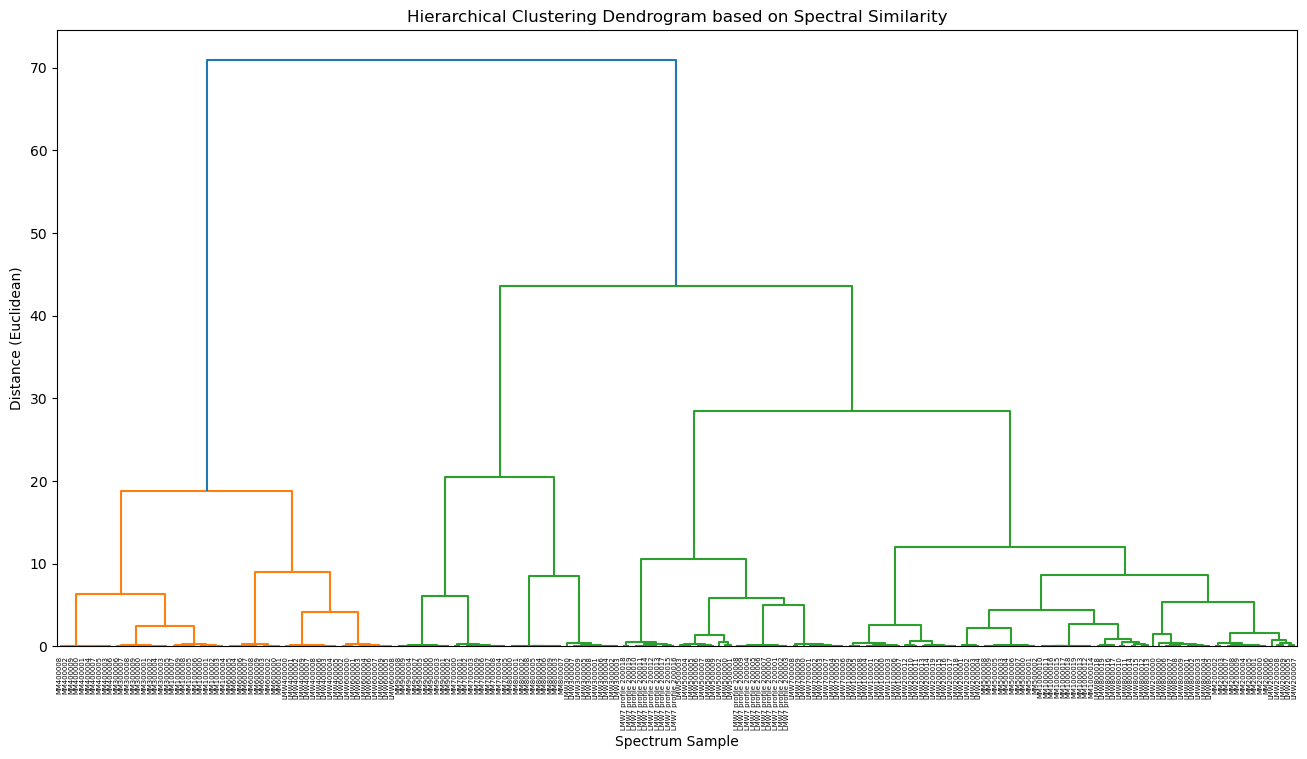

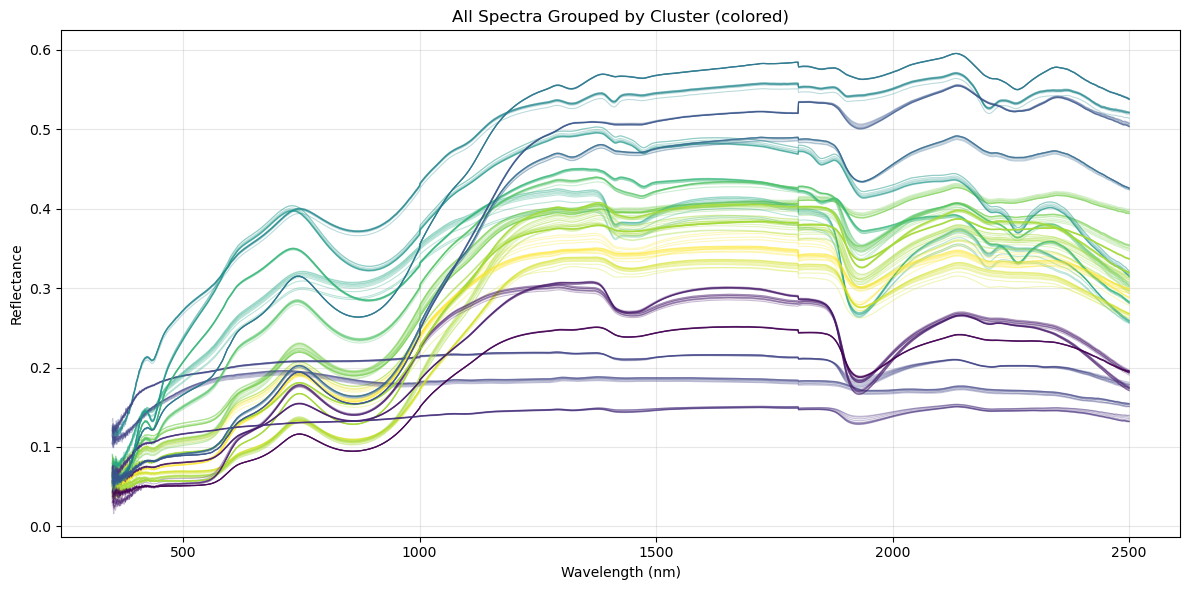

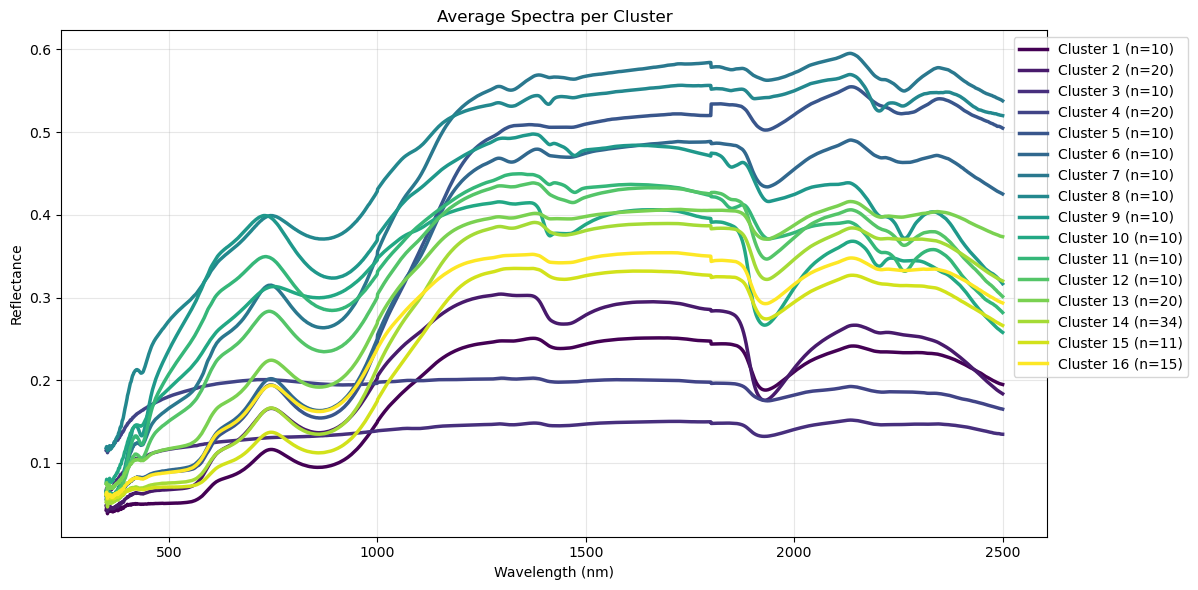

Cluster Assignment:
        Sample  Cluster
0    LMW100000       13
1    LMW100001       13
2    LMW100002       13
3    LMW100003       13
4    LMW100004       13
..         ...      ...
215   MM900005        5
216   MM900006        5
217   MM900007        5
218   MM900008        5
219   MM900009        5

[220 rows x 2 columns]

Number of clusters: 16
Cluster 1: 10 samples - ['MM400000', 'MM400001', 'MM400002', 'MM400003', 'MM400004']...
Cluster 2: 20 samples - ['MM100000', 'MM100001', 'MM100002', 'MM100003', 'MM100004']...
Cluster 3: 10 samples - ['MM600000', 'MM600001', 'MM600002', 'MM600003', 'MM600004']...
Cluster 4: 20 samples - ['LMW400000', 'LMW400001', 'LMW400002', 'LMW400003', 'LMW400004']...
Cluster 5: 10 samples - ['MM900000', 'MM900001', 'MM900002', 'MM900003', 'MM900004']...
Cluster 6: 10 samples - ['MM700000', 'MM700001', 'MM700002', 'MM700003', 'MM700004']...
Cluster 7: 10 samples - ['MM800000', 'MM800001', 'MM800002', 'MM800003', 'MM800004']...
Cluster 8: 10 samples -

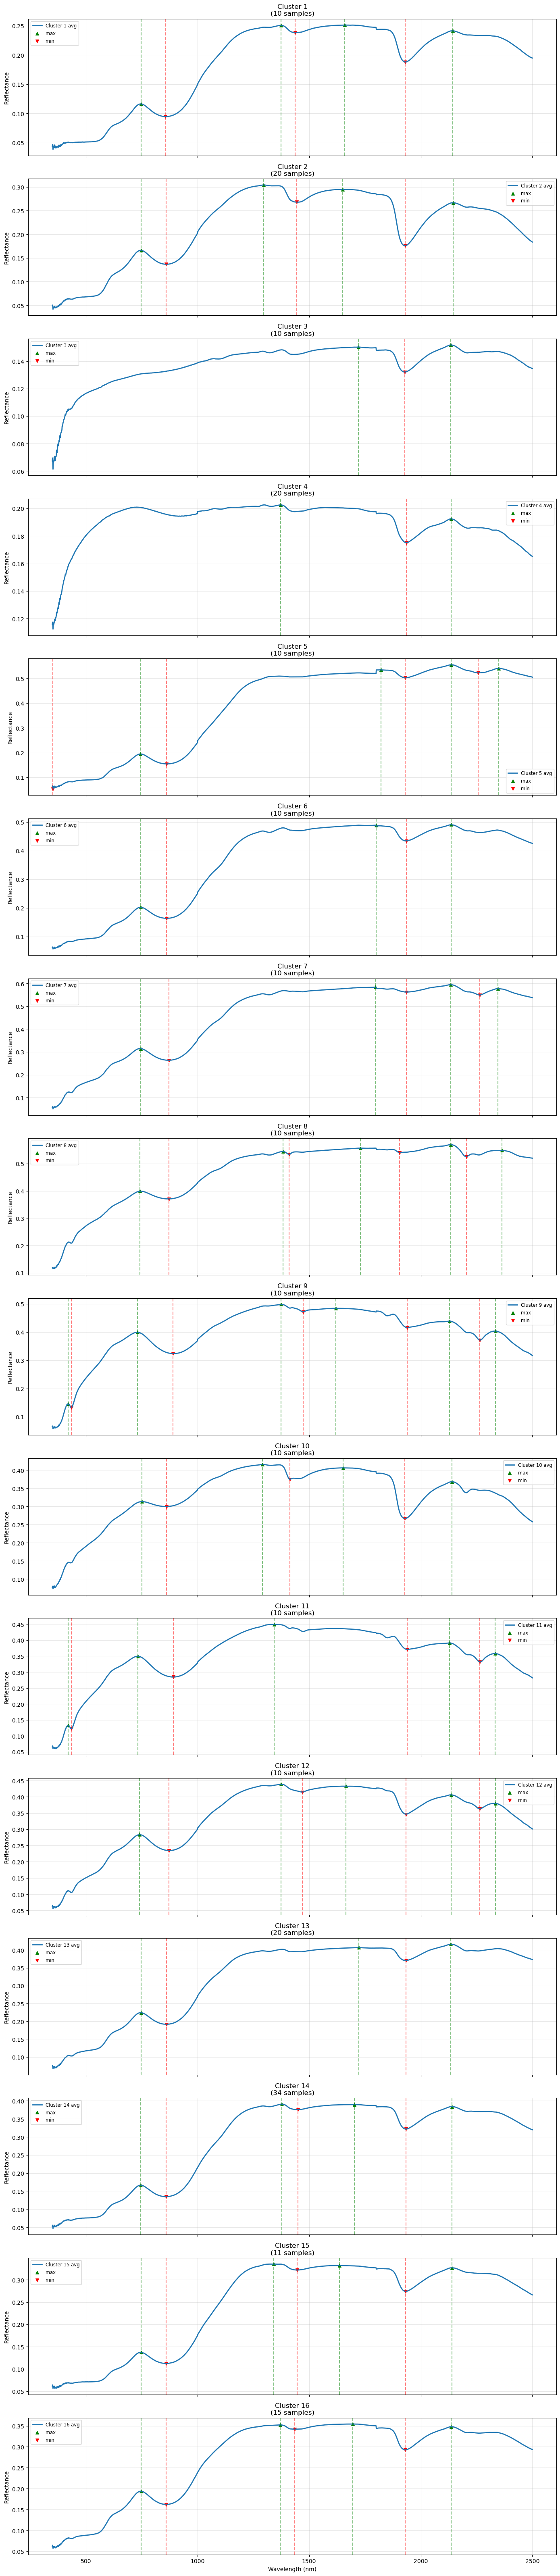


Cluster 1 extrema (count max=4, min=3)
Maxima (wavelength, reflectance):
 Wavelength  Reflectance
        747     0.116311
       1375     0.250681
       1660     0.251256
       2143     0.241372
Minima (wavelength, reflectance):
 Wavelength  Reflectance
        856     0.094648
       1438     0.238315
       1931     0.188070

Cluster 2 extrema (count max=4, min=3)
Maxima (wavelength, reflectance):
 Wavelength  Reflectance
        747     0.166021
       1296     0.304150
       1651     0.294945
       2146     0.266548
Minima (wavelength, reflectance):
 Wavelength  Reflectance
        860     0.136540
       1444     0.267883
       1930     0.175749

Cluster 3 extrema (count max=2, min=1)
Maxima (wavelength, reflectance):
 Wavelength  Reflectance
       1720     0.150301
       2135     0.151822
Minima (wavelength, reflectance):
 Wavelength  Reflectance
       1928     0.132101

Cluster 4 extrema (count max=2, min=1)
Maxima (wavelength, reflectance):
 Wavelength  Reflectance
  

In [13]:
#group1 asd
data_folder = 'Data_folders/Group_1_ASD/'

# Load data
alldata = load_asd_data(data_folder)
if alldata is None:
    raise ValueError("Failed to load data")

# Plot average spectrum
plot_average_spectrum(alldata, name="Pictures/average_spectrum_group1_asd.png")

# Perform clustering
linkage_matrix, cluster_assignment, num_clusters, cluster_averages = perform_clustering(alldata, num_clusters=16)

# Plot dendrogram
spectrum_data = alldata.drop('Avg refl', axis=1)
plot_dendrogram(linkage_matrix, spectrum_data, name="Pictures/dendrogram_group1_asd.png")

# Plot spectra and averages
plot_spectra_and_averages(spectrum_data, cluster_assignment, num_clusters, cluster_averages, name_All="Pictures/all_spectra_clusters_group1_asd.png", name_clus="Pictures/cluster_averages_group1_asd.png")

# Print cluster summary
print_cluster_summary(cluster_assignment, num_clusters)

# Analyze extrema
analyze_extrema(cluster_averages, cluster_assignment, name="Pictures/cluster_extrema_group1_asd.png")

C:\Users\fionn\AppData\Local\Temp\ipykernel_22012\29315350.py:40: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  fallback = pd.read_csv(f, delim_whitespace=True, header=None, skiprows=1, names=['wavelength', 'reflectance'])
C:\Users\fionn\AppData\Local\Temp\ipykernel_22012\29315350.py:40: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  fallback = pd.read_csv(f, delim_whitespace=True, header=None, skiprows=1, names=['wavelength', 'reflectance'])
C:\Users\fionn\AppData\Local\Temp\ipykernel_22012\29315350.py:40: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  fallback = pd.read_csv(f, delim_whitespace=True, header=None, skiprows=1, names=['wavelength', 'reflectance'])
C:\Users\fionn\AppData\Local\Temp\ipy

Data loaded successfully. Shape: (2151, 211)
            LMW_1000000  LMW_1000001  LMW_1000002  LMW_1000003  LMW_1000004  \
wavelength                                                                    
350            0.046082     0.033932     0.046782     0.034002     0.047712   
351            0.043652     0.045085     0.051281     0.040048     0.047241   
352            0.040523     0.047812     0.048304     0.044246     0.044864   
353            0.035285     0.035024     0.039583     0.040433     0.041936   
354            0.044930     0.043009     0.039710     0.039181     0.048584   

            LMW_1000005  LMW_1000006  LMW_1000007  LMW_1000008  LMW_1000009  \
wavelength                                                                    
350            0.042383     0.058818     0.042874     0.046664     0.047889   
351            0.049680     0.058892     0.053735     0.053161     0.051638   
352            0.049759     0.052997     0.052098     0.050245     0.049367   
353   

C:\Users\fionn\AppData\Local\Temp\ipykernel_22012\29315350.py:40: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  fallback = pd.read_csv(f, delim_whitespace=True, header=None, skiprows=1, names=['wavelength', 'reflectance'])
C:\Users\fionn\AppData\Local\Temp\ipykernel_22012\29315350.py:40: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  fallback = pd.read_csv(f, delim_whitespace=True, header=None, skiprows=1, names=['wavelength', 'reflectance'])
C:\Users\fionn\AppData\Local\Temp\ipykernel_22012\29315350.py:40: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  fallback = pd.read_csv(f, delim_whitespace=True, header=None, skiprows=1, names=['wavelength', 'reflectance'])
C:\Users\fionn\AppData\Local\Temp\ipy

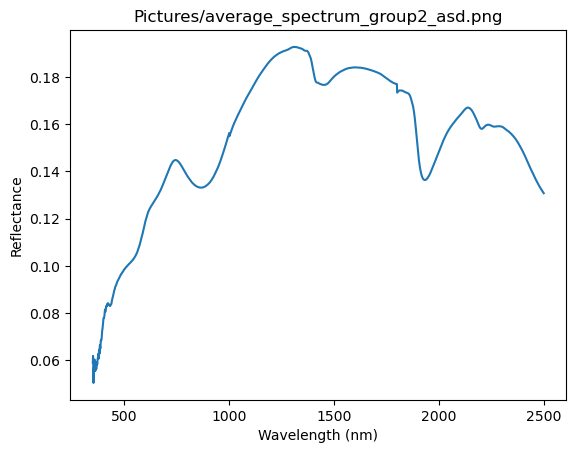

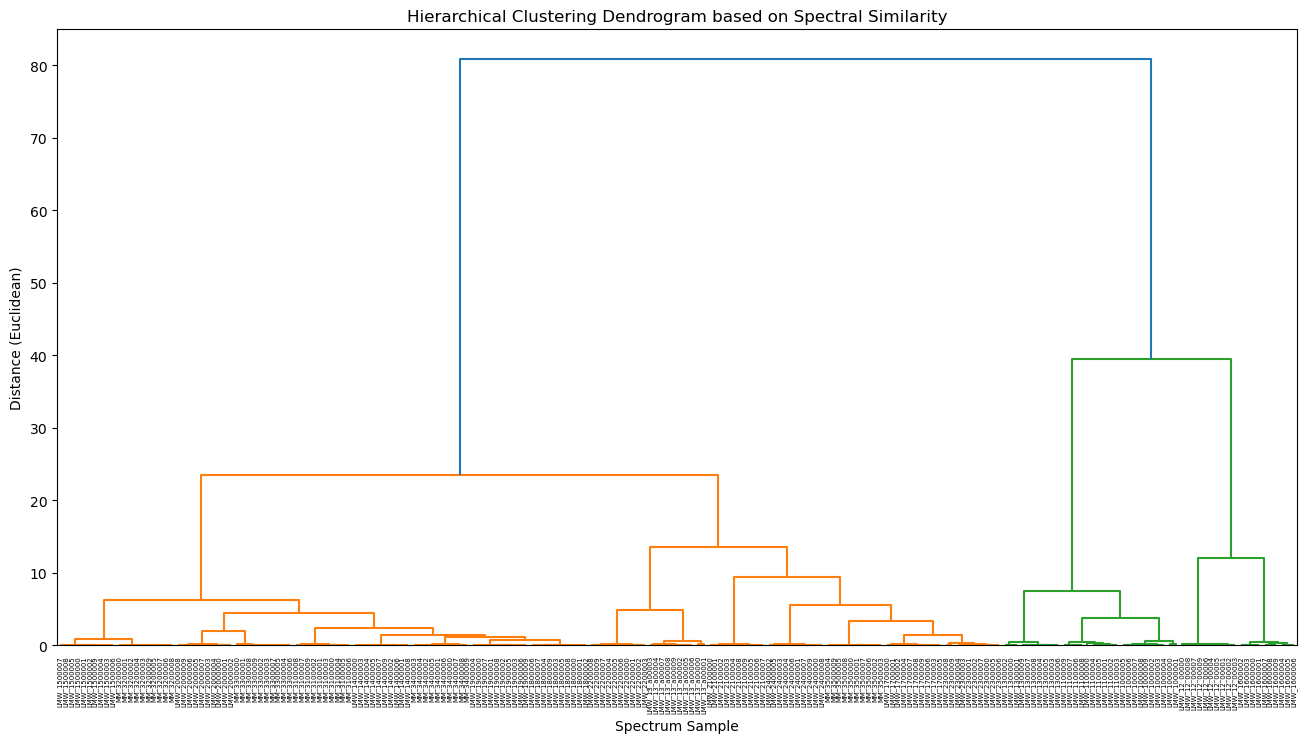

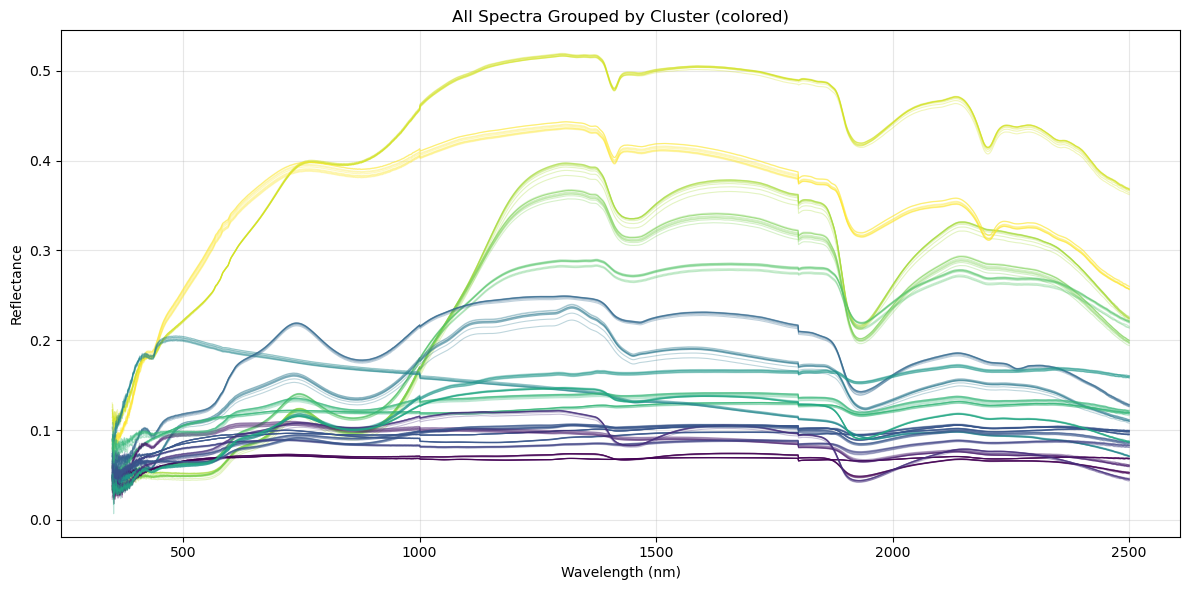

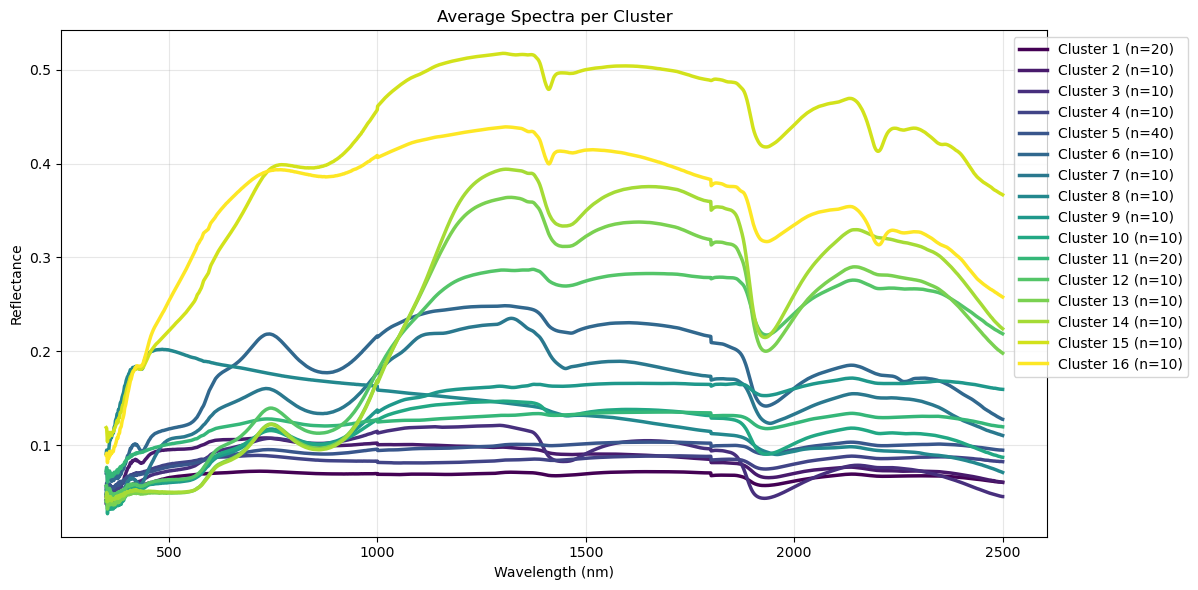

Cluster Assignment:
          Sample  Cluster
0    LMW_1000000       14
1    LMW_1000001       14
2    LMW_1000002       14
3    LMW_1000003       14
4    LMW_1000004       14
..           ...      ...
205   MM_3500005       10
206   MM_3500006       10
207   MM_3500007       10
208   MM_3500008       10
209   MM_3500009       10

[210 rows x 2 columns]

Number of clusters: 16
Cluster 1: 20 samples - ['LMW_1500000', 'LMW_1500001', 'LMW_1500002', 'LMW_1500003', 'LMW_1500004']...
Cluster 2: 10 samples - ['LMW_2000000', 'LMW_2000001', 'LMW_2000002', 'LMW_2000003', 'LMW_2000004']...
Cluster 3: 10 samples - ['MM_3300000', 'MM_3300001', 'MM_3300002', 'MM_3300003', 'MM_3300004']...
Cluster 4: 10 samples - ['MM_3100000', 'MM_3100001', 'MM_3100002', 'MM_3100003', 'MM_3100004']...
Cluster 5: 40 samples - ['LMW_1400000', 'LMW_1400001', 'LMW_1400002', 'LMW_1400003', 'LMW_1400004']...
Cluster 6: 10 samples - ['LMW_2200000', 'LMW_2200001', 'LMW_2200002', 'LMW_2200003', 'LMW_2200004']...
Cluster 7: 1

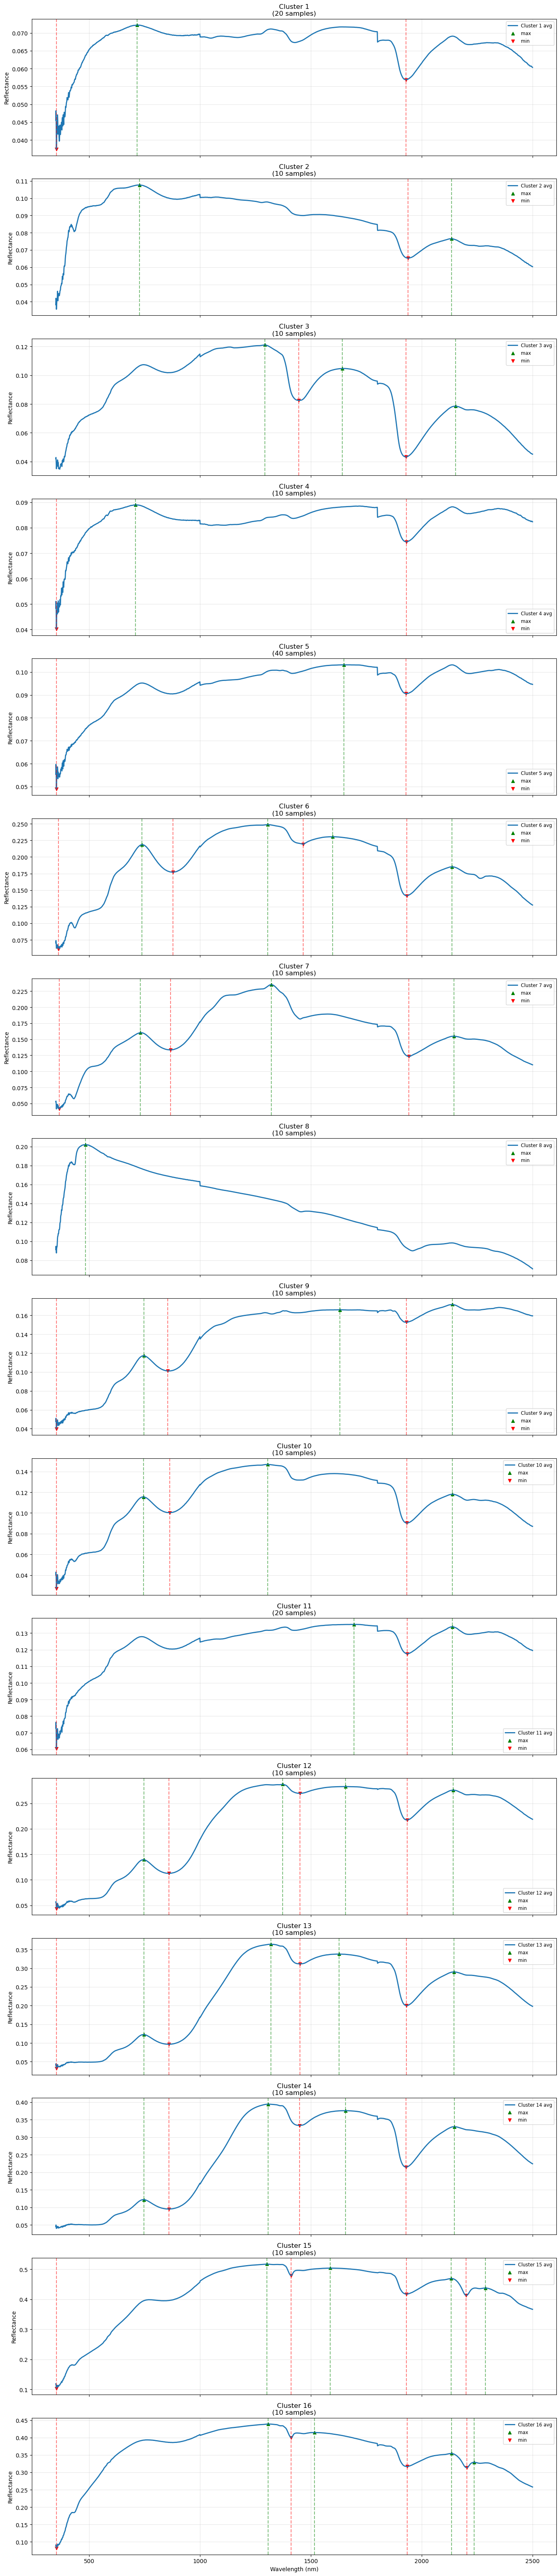


Cluster 1 extrema (count max=1, min=2)
Maxima (wavelength, reflectance):
 Wavelength  Reflectance
        716     0.072195
Minima (wavelength, reflectance):
 Wavelength  Reflectance
        353     0.037382
       1930     0.056905

Cluster 2 extrema (count max=2, min=1)
Maxima (wavelength, reflectance):
 Wavelength  Reflectance
        728      0.10764
       2135      0.07651
Minima (wavelength, reflectance):
 Wavelength  Reflectance
       1938     0.065268

Cluster 3 extrema (count max=3, min=2)
Maxima (wavelength, reflectance):
 Wavelength  Reflectance
       1293     0.121067
       1643     0.104696
       2153     0.078496
Minima (wavelength, reflectance):
 Wavelength  Reflectance
       1445     0.082512
       1929     0.043257

Cluster 4 extrema (count max=1, min=2)
Maxima (wavelength, reflectance):
 Wavelength  Reflectance
        710     0.089019
Minima (wavelength, reflectance):
 Wavelength  Reflectance
        353     0.040123
       1931     0.074477

Cluster 5 extrema

In [14]:
#group2 asd
data_folder = 'Data_folders/Group_2_ASD/'

# Load data
alldata = load_asd_data(data_folder)
if alldata is None:
    raise ValueError("Failed to load data")

# Plot average spectrum
plot_average_spectrum(alldata, name="Pictures/average_spectrum_group2_asd.png")

# Perform clustering
linkage_matrix, cluster_assignment, num_clusters, cluster_averages = perform_clustering(alldata, num_clusters=16)

# Plot dendrogram
spectrum_data = alldata.drop('Avg refl', axis=1)
plot_dendrogram(linkage_matrix, spectrum_data, name="Pictures/dendrogram_group2_asd.png")

# Plot spectra and averages
plot_spectra_and_averages(spectrum_data, cluster_assignment, num_clusters, cluster_averages, name_All="Pictures/all_spectra_clusters_group2_asd.png", name_clus="Pictures/cluster_averages_group2_asd.png")

# Print cluster summary
print_cluster_summary(cluster_assignment, num_clusters)

# Analyze extrema
analyze_extrema(cluster_averages, cluster_assignment, name="Pictures/cluster_extrema_group2_asd.png")

C:\Users\fionn\AppData\Local\Temp\ipykernel_22012\29315350.py:40: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  fallback = pd.read_csv(f, delim_whitespace=True, header=None, skiprows=1, names=['wavelength', 'reflectance'])
C:\Users\fionn\AppData\Local\Temp\ipykernel_22012\29315350.py:40: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  fallback = pd.read_csv(f, delim_whitespace=True, header=None, skiprows=1, names=['wavelength', 'reflectance'])
C:\Users\fionn\AppData\Local\Temp\ipykernel_22012\29315350.py:40: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  fallback = pd.read_csv(f, delim_whitespace=True, header=None, skiprows=1, names=['wavelength', 'reflectance'])
C:\Users\fionn\AppData\Local\Temp\ipy

Data loaded successfully. Shape: (2151, 211)
            lmw-9-100000  lmw-9-100001  lmw-9-100002  lmw-9-100003  \
wavelength                                                           
350             0.088903      0.115106      0.101169      0.094811   
351             0.097544      0.112308      0.109604      0.094507   
352             0.091941      0.099503      0.104103      0.092811   
353             0.072885      0.089016      0.085401      0.096104   
354             0.091887      0.088759      0.092036      0.098066   

            lmw-9-100004  lmw-9-100005  lmw-9-100006  lmw-9-100007  \
wavelength                                                           
350             0.098278      0.097768      0.106155      0.110198   
351             0.106731      0.101363      0.103218      0.109282   
352             0.103427      0.102169      0.095383      0.097355   
353             0.084004      0.092682      0.091026      0.081732   
354             0.090912      0.094740      

C:\Users\fionn\AppData\Local\Temp\ipykernel_22012\29315350.py:40: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  fallback = pd.read_csv(f, delim_whitespace=True, header=None, skiprows=1, names=['wavelength', 'reflectance'])
C:\Users\fionn\AppData\Local\Temp\ipykernel_22012\29315350.py:40: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  fallback = pd.read_csv(f, delim_whitespace=True, header=None, skiprows=1, names=['wavelength', 'reflectance'])
C:\Users\fionn\AppData\Local\Temp\ipykernel_22012\29315350.py:40: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  fallback = pd.read_csv(f, delim_whitespace=True, header=None, skiprows=1, names=['wavelength', 'reflectance'])
C:\Users\fionn\AppData\Local\Temp\ipy

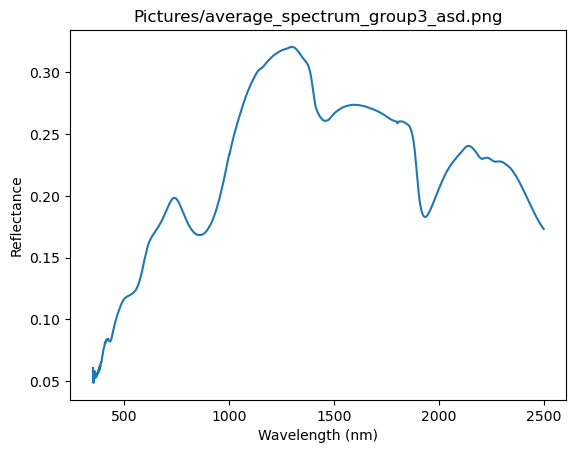

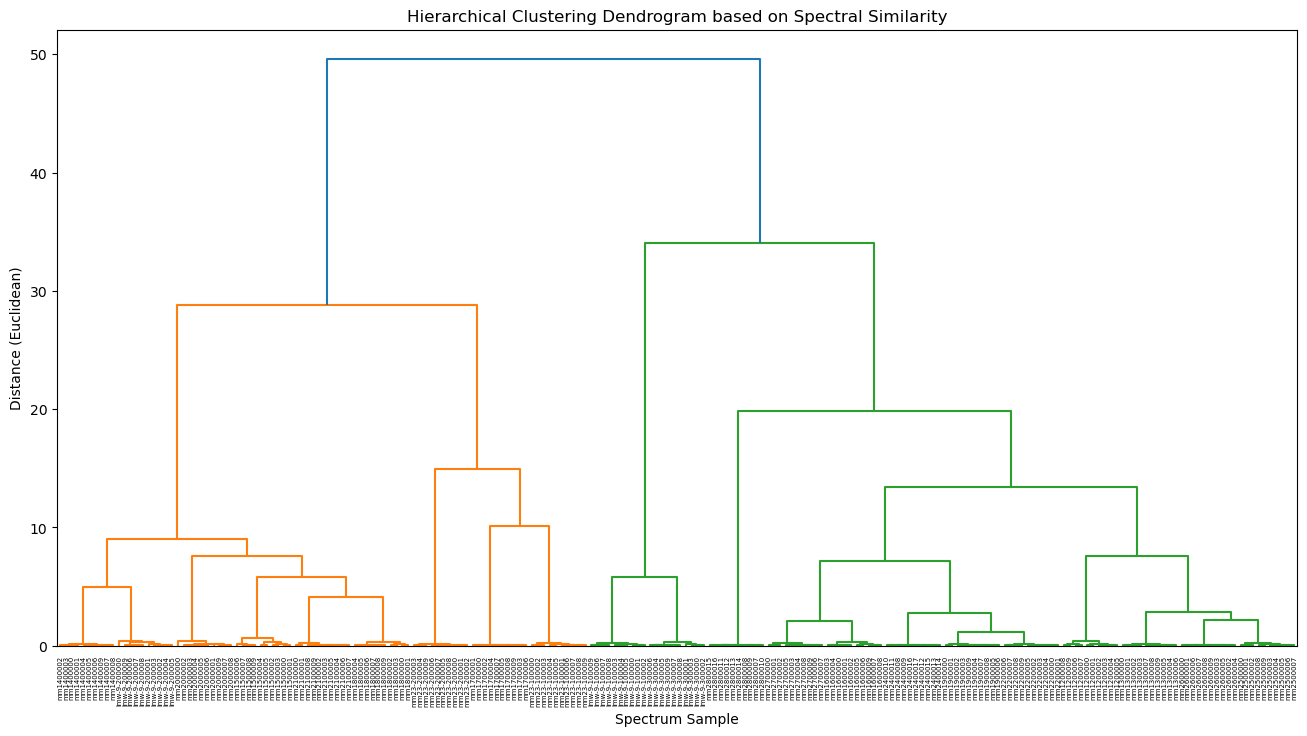

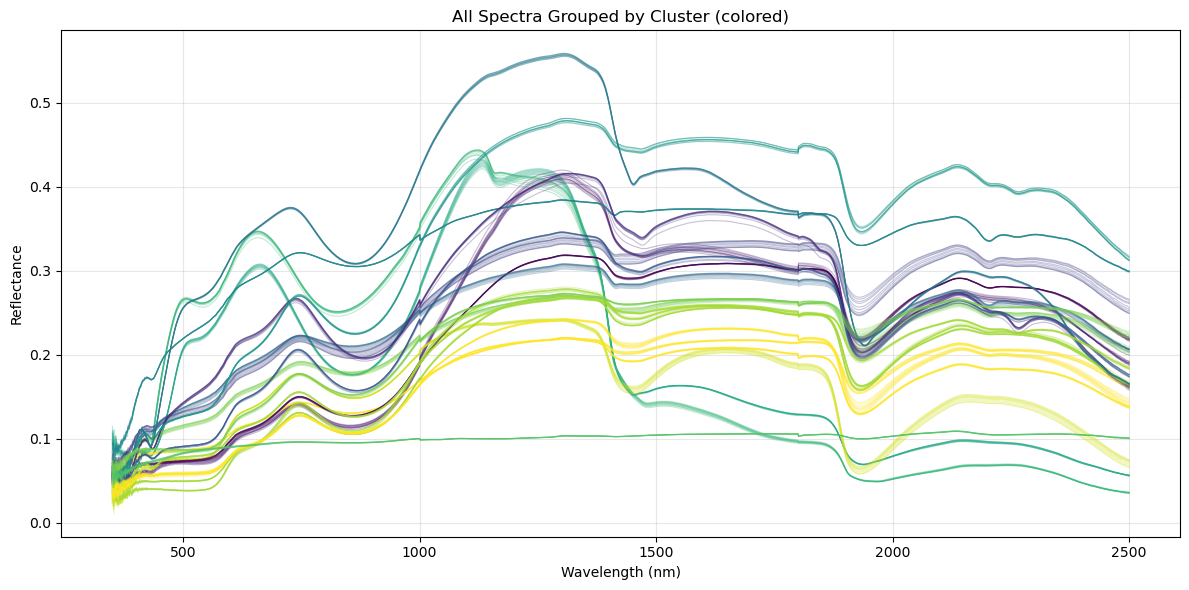

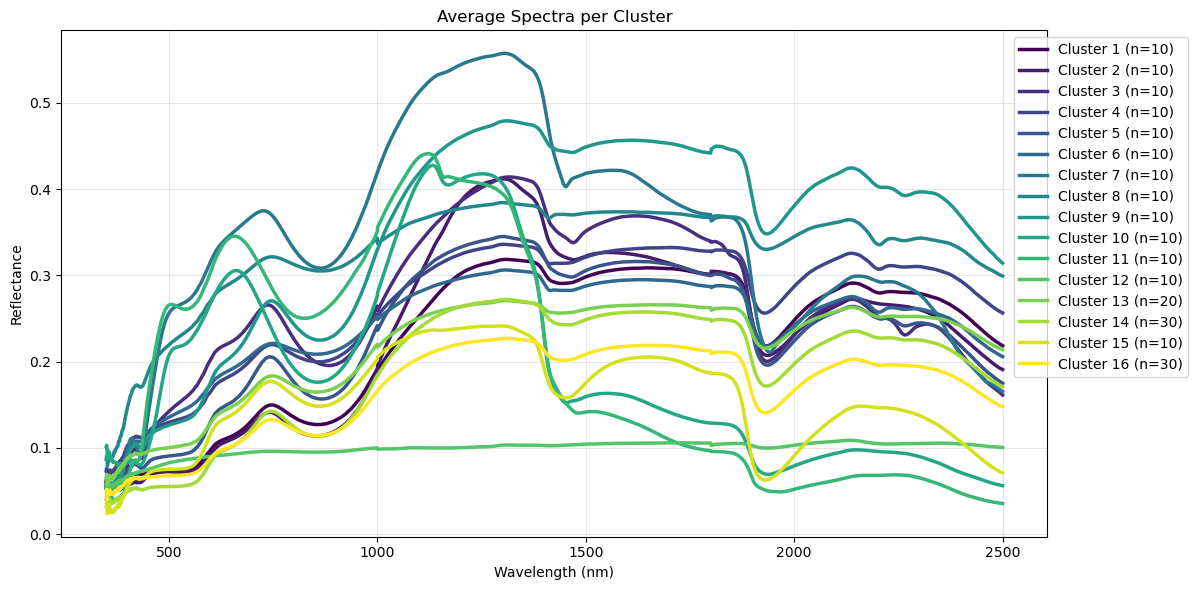

Cluster Assignment:
           Sample  Cluster
0    lmw-9-100000       10
1    lmw-9-100001       10
2    lmw-9-100002       10
3    lmw-9-100003       10
4    lmw-9-100004       10
..            ...      ...
205     mm2800012       12
206     mm2800013       12
207     mm2800014       12
208     mm2800015       12
209     mm2800016       12

[210 rows x 2 columns]

Number of clusters: 16
Cluster 1: 10 samples - ['mm1400000', 'mm1400001', 'mm1400002', 'mm1400003', 'mm1400004']...
Cluster 2: 10 samples - ['lmw-9-200000', 'lmw-9-200001', 'lmw-9-200002', 'lmw-9-200003', 'lmw-9-200004']...
Cluster 3: 10 samples - ['mm2000000', 'mm2000001', 'mm2000002', 'mm2000003', 'mm2000004']...
Cluster 4: 10 samples - ['mm1500000', 'mm1500001', 'mm1500002', 'mm1500003', 'mm1500004']...
Cluster 5: 10 samples - ['mm2100000', 'mm2100001', 'mm2100002', 'mm2100003', 'mm2100004']...
Cluster 6: 10 samples - ['mm1800000', 'mm1800001', 'mm1800002', 'mm1800003', 'mm1800004']...
Cluster 7: 10 samples - ['mm23-2000

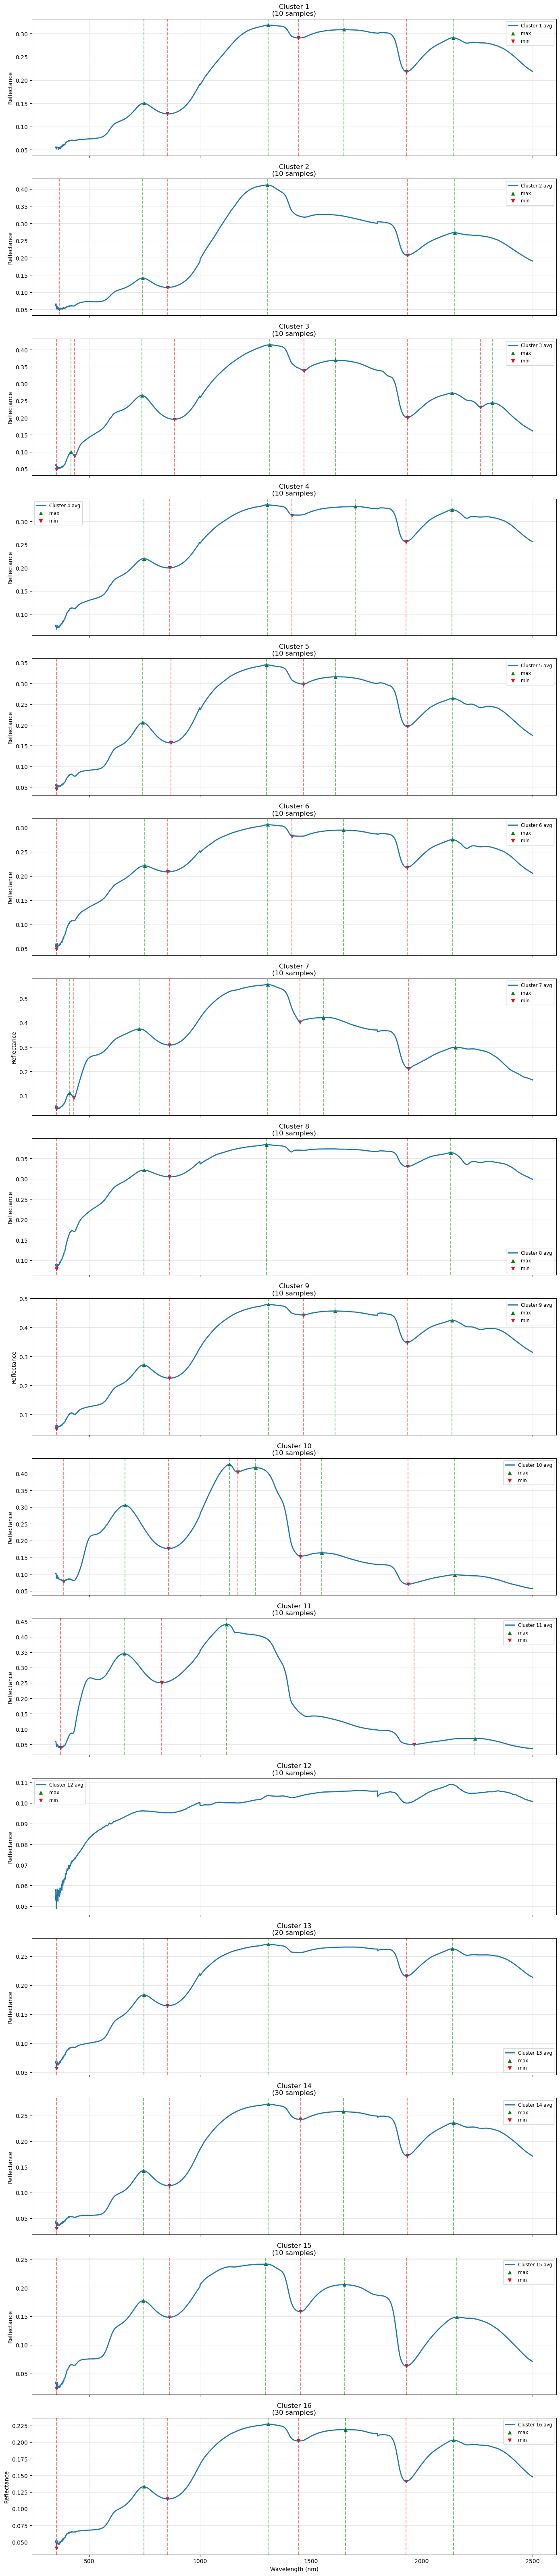


Cluster 1 extrema (count max=4, min=3)
Maxima (wavelength, reflectance):
 Wavelength  Reflectance
        748     0.149848
       1307     0.318519
       1649     0.308743
       2142     0.291059
Minima (wavelength, reflectance):
 Wavelength  Reflectance
        853     0.127116
       1444     0.290640
       1932     0.218127

Cluster 2 extrema (count max=3, min=3)
Maxima (wavelength, reflectance):
 Wavelength  Reflectance
        743     0.141277
       1304     0.411738
       2150     0.273021
Minima (wavelength, reflectance):
 Wavelength  Reflectance
        366     0.050447
        855     0.113920
       1936     0.207276

Cluster 3 extrema (count max=6, min=6)
Maxima (wavelength, reflectance):
 Wavelength  Reflectance
        419     0.099019
        738     0.265763
       1315     0.413979
       1612     0.369008
       2137     0.272733
       2319     0.243577
Minima (wavelength, reflectance):
 Wavelength  Reflectance
        353     0.049040
        435     0.088036
 

In [15]:
#group3 asd
data_folder = 'Data_folders/Group_3_ASD/'

# Load data
alldata = load_asd_data(data_folder)
if alldata is None:
    raise ValueError("Failed to load data")

# Plot average spectrum
plot_average_spectrum(alldata, name="Pictures/average_spectrum_group3_asd.png")

# Perform clustering
linkage_matrix, cluster_assignment, num_clusters, cluster_averages = perform_clustering(alldata, num_clusters=16)

# Plot dendrogram
spectrum_data = alldata.drop('Avg refl', axis=1)
plot_dendrogram(linkage_matrix, spectrum_data, name="Pictures/dendrogram_group3_asd.png")

# Plot spectra and averages
plot_spectra_and_averages(spectrum_data, cluster_assignment, num_clusters, cluster_averages, name_All="Pictures/all_spectra_clusters_group3_asd.png", name_clus="Pictures/cluster_averages_group3_asd.png")

# Print cluster summary
print_cluster_summary(cluster_assignment, num_clusters)

# Analyze extrema
analyze_extrema(cluster_averages, cluster_assignment, name="Pictures/cluster_extrema_group3_asd.png")